In [3]:
import pandas as pd
df = pd.read_csv ("patient_readmission.csv")

print (df.head())
print (df.shape)
print (df.columns)

   Patient_ID  age  gender primary_diagnosis  num_procedures  \
0           1   52    Male     Heart Disease               3   
1           2   47  Female          Diabetes               2   
2           3   72  Female     Heart Disease               7   
3           4   18  Female              COPD               5   
4           5   32    Male     Heart Disease               9   

   days_in_hospital  comorbidity_score              discharge_to  readmitted  
0                 9                  3                      Home           1  
1                 4                  0  Skilled Nursing Facility           0  
2                12                  4                      Home           1  
3                14                  3                      Home           1  
4                 2                  4   Rehabilitation Facility           1  
(2000, 9)
Index(['Patient_ID', 'age', 'gender', 'primary_diagnosis', 'num_procedures',
       'days_in_hospital', 'comorbidity_score', 'disch

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Patient_ID         2000 non-null   int64
 1   age                2000 non-null   int64
 2   gender             2000 non-null   str  
 3   primary_diagnosis  2000 non-null   str  
 4   num_procedures     2000 non-null   int64
 5   days_in_hospital   2000 non-null   int64
 6   comorbidity_score  2000 non-null   int64
 7   discharge_to       2000 non-null   str  
 8   readmitted         2000 non-null   int64
dtypes: int64(6), str(3)
memory usage: 140.8 KB
None


In [5]:
print(df.isnull().sum())

Patient_ID           0
age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df = df.drop_duplicates()

In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

import joblib

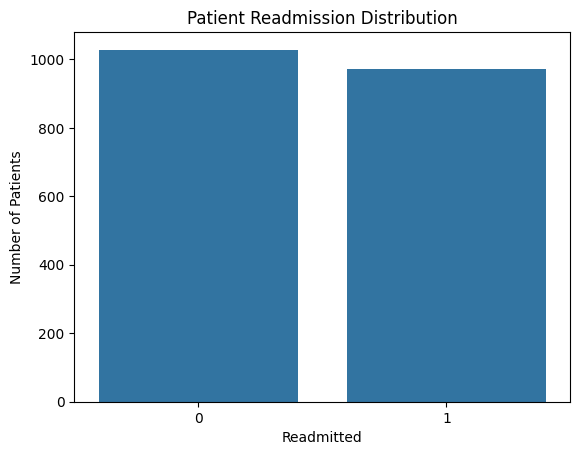

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x="readmitted")
plt.title("Patient Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
plt.show()

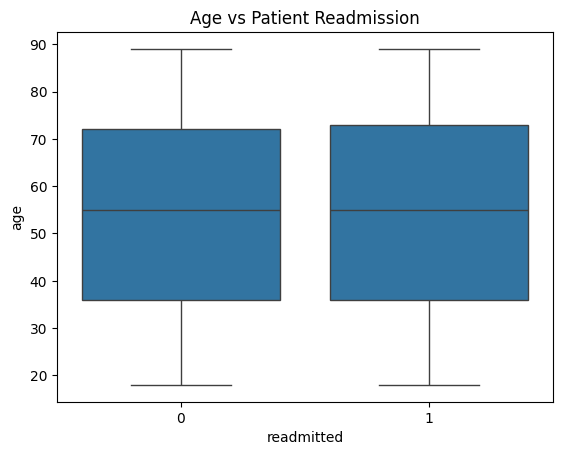

In [11]:
sns.boxplot(data=df, x="readmitted", y="age")
plt.title("Age vs Patient Readmission")
plt.show()

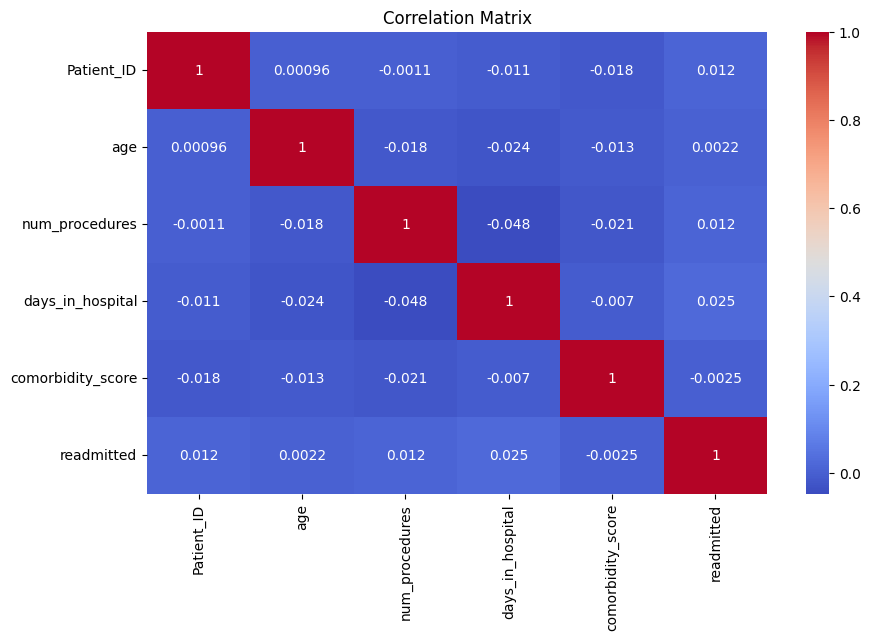

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [13]:
df["readmitted"] = df["readmitted"].map({
    "Yes": 1,
    "No": 0
})

In [14]:
print(df["readmitted"].value_counts())

Series([], Name: count, dtype: int64)


In [15]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

In [16]:
if "patient_id" in X.columns:
    X = X.drop("patient_id", axis=1)